# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except Exception:
        # Tải trực tiếp từ link lưu trữ dữ liệu gốc UCI nếu không có file & ucimlrepo chưa cài
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
        df = pd.read_csv(url)
        source = 'UCI direct URL download'

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())

Nguồn: UCI direct URL download
Dữ liệu đầy đủ: 440 dòng × 8 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?

Mỗi dòng là 1 khách hàng bán buôn (Wholesale Customer) ghi nhận tổng số tiền chi tiêu hàng năm (Annual Spending) cho 6 nhóm sản phẩm: Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen.  
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?

Đặc tính dữ liệu: Không có missing values. Dữ liệu bị lệch phải nặng (Right-skewed) với nhiều điểm outlier (các đại lý/chuỗi bán lẻ cực lớn).
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?

Không đưa vào model phân cụm ban đầu vì chúng là biến phân loại địa lý/kênh phân phối. Chúng sẽ được dùng ở giai đoạn validate (cross-tabulation) để kiểm tra xem các cụm tìm được theo hành vi chi tiêu có tương quan với phân bố kênh phân phối thực tế hay không.
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

"Hữu ích" nghĩa là các cụm phải phân hóa rõ nét về mặt hành vi/nhu cầu sản phẩm (ví dụ: nhóm chuyên thực phẩm tươi vs. nhóm chuyên hàng tiêu dùng/bán lẻ) để phòng Mua hàng & Marketing đưa ra chiến lược tối ưu tồn kho và gói ưu đãi thích hợp.
Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [4]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Summary Statistics (Raw Data) ---")
display(X_raw.describe().T)

--- Missing Values ---
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

--- Summary Statistics (Raw Data) ---


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7911 (\N{LATIN SMALL LETTER U WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7919 (\N{LATIN SMALL LETTER U WITH HORN AND TILDE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


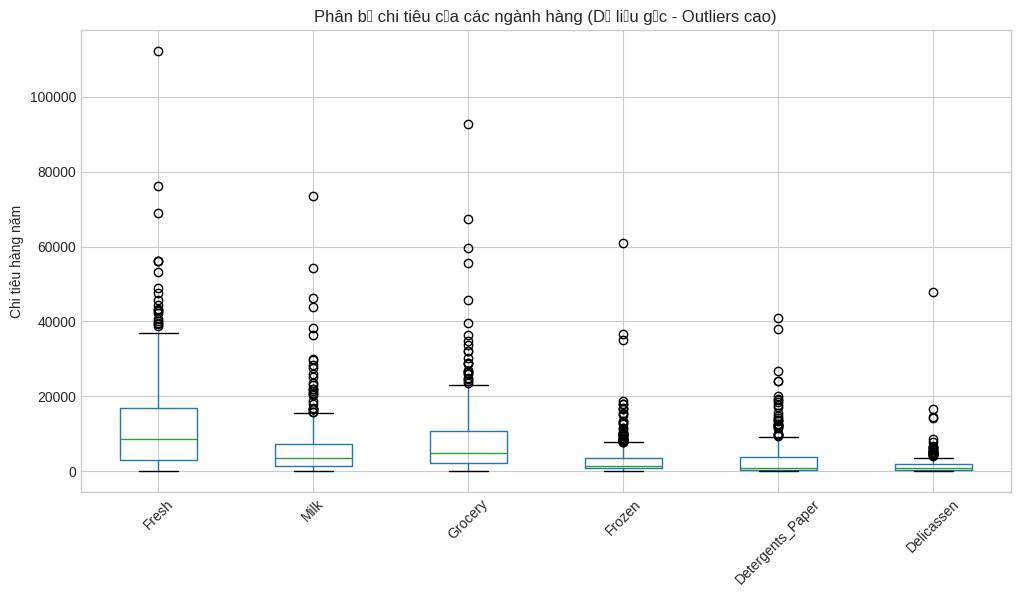

In [5]:
plt.figure(figsize=(12, 6))
X_raw.boxplot(rot=45)
plt.title("Phân bố chi tiêu của các ngành hàng (Dữ liệu gốc - Outliers cao)")
plt.ylabel("Chi tiêu hàng năm")
plt.show()

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [6]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))
X_log = np.log1p(X_raw)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_model = pd.DataFrame(X_scaled, columns=SPENDING_FEATURES)

print("Đã hoàn thành tiền xử lý: Log1p + StandardScaler")

Đã hoàn thành tiền xử lý: Log1p + StandardScaler


# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [7]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)
results = []
k_range = range(2, 6)

for k in k_range:
    # 1. KMeans
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(X_model)
    km_sil = silhouette_score(X_model, km_labels)
    km_db = davies_bouldin_score(X_model, km_labels)
    results.append({'Algorithm': 'KMeans', 'K': k, 'Silhouette': km_sil, 'Davies-Bouldin': km_db})

    # 2. Hierarchical (Ward)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agg.fit_predict(X_model)
    agg_sil = silhouette_score(X_model, agg_labels)
    agg_db = davies_bouldin_score(X_model, agg_labels)
    results.append({'Algorithm': 'Hierarchical-Ward', 'K': k, 'Silhouette': agg_sil, 'Davies-Bouldin': agg_db})

df_eval = pd.DataFrame(results)
display(df_eval)

# Chọn Model cuối cùng: KMeans với K=3 (hoặc K=2 tùy theo kết quả silhouette tốt nhất)
FINAL_K = 3
final_model = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
labels_final = final_model.fit_predict(X_model)

# Stability Check (Kiểm tra độ ổn định bằng ARI với random_state khác)
km_check = KMeans(n_clusters=FINAL_K, random_state=2026, n_init=10)
labels_check = km_check.fit_predict(X_model)
ari_score = adjusted_rand_score(labels_final, labels_check)
print(f"Adjusted Rand Index (Stability Check across seeds): {ari_score:.4f}")

,Algorithm,K,Silhouette,Davies-Bouldin
0,KMeans,2,0.29,1.35
1,Hierarchical-Ward,2,0.26,1.60
2,KMeans,3,0.26,1.34
3,Hierarchical-Ward,3,0.25,1.54
4,KMeans,4,0.19,1.54
5,Hierarchical-Ward,4,0.20,1.52
6,KMeans,5,0.19,1.48
7,Hierarchical-Ward,5,0.20,1.39


Adjusted Rand Index (Stability Check across seeds): 0.9936


# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7899 (\N{LATIN SMALL LETTER O WITH HORN AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7909 (\N{LATIN SMA

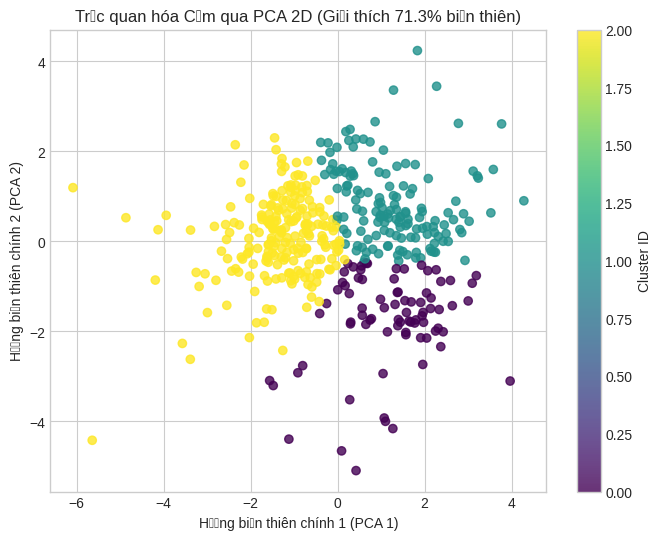

In [8]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_model)
var_explained = pca.explained_variance_ratio_.sum() * 100

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], c=labels_final, cmap='viridis', alpha=0.8)
plt.title(f"Trực quan hóa Cụm qua PCA 2D (Giải thích {var_explained:.1f}% biến thiên)")
plt.xlabel("Hướng biến thiên chính 1 (PCA 1)")
plt.ylabel("Hướng biến thiên chính 2 (PCA 2)")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

--- Cluster Profile (Median Chi tiêu theo đơn vị gốc) ---


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,"1,492.50","6,300.50","10,502.50",376.00,"4,217.50",434.50
1,"12,126.00","7,184.00","9,965.00","2,005.00","3,378.00","2,005.00"
2,"9,612.00","1,601.00","2,155.00","2,121.00",274.00,686.00


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7883 (\N{LATIN SMALL LETTER I WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7909 (\N{LATIN SMALL LETTER U WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


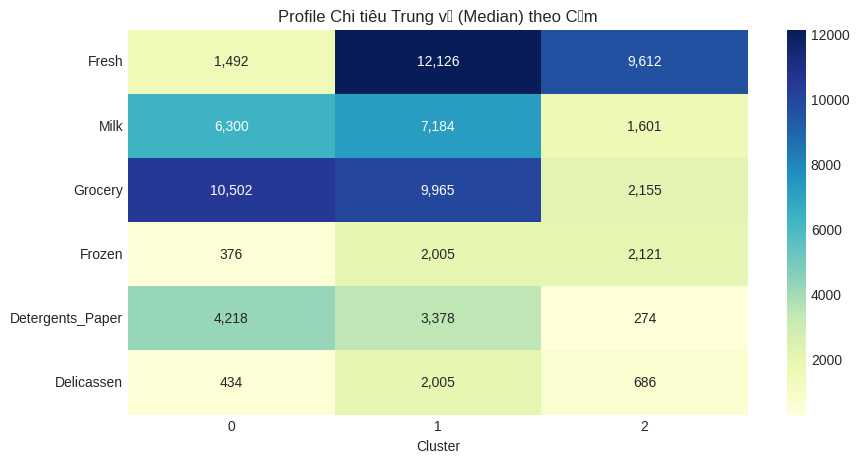

In [10]:
import seaborn as sns  # Bổ sung import seaborn để tránh lỗi NameError

# Phân tích Profile dựa trên Median đơn vị gốc (X_raw)
X_profile = X_raw.copy()
X_profile['Cluster'] = labels_final

profile_median = X_profile.groupby('Cluster').median()
print("--- Cluster Profile (Median Chi tiêu theo đơn vị gốc) ---")
display(profile_median)

# Trực quan hóa Heatmap Profile
plt.figure(figsize=(10, 5))
sns.heatmap(profile_median.T, annot=True, fmt=',.0f', cmap='YlGnBu')
plt.title("Profile Chi tiêu Trung vị (Median) theo Cụm")
plt.show()

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.
